In [43]:
%matplotlib inline
import numpy as np
#import time
import os
import matplotlib.pyplot as plt
#import scraps as scr
import pickle as pk
import warnings
import glob
import lmfit as lf
from scipy.special import digamma, i0, k0
import scipy.constants as sc
#import res_fit_models as rfm
#import res_misc_funcs as miscfun
#import LNA_sweep_config as cg
warnings.filterwarnings('ignore')

def f0_tls(params, temps, powers, data = None, eps = None, **kwargs):
    """A model of frequency shift vs temperature and power, weighted by uncertainties.

    Parameters
    ----------
    params : ``lmfit.Parameters`` object
        Parameters must include ``['Fd', 'df', 'fRef', 'alpha', 'delta0']``.

    temps : ``numpy.Array``
        Array of temperature values to evaluate model at. May be 2D.

    powers : ``numpy.Array``
        Array of power values to evaluate model at. May be 2D.

    data : ``numpy.Array``
        Data values to compare to model. May also be ``None``, in which case
        function returns model.

    eps : ``numpy.Array``
        Uncertianties with which to weight residual. May also be ``None``, in
        which case residual is unwieghted.

    Returns
    -------

    residual : ``numpy.Array``
        The weighted or unweighted vector of residuals if ``data`` is passed.
        Otherwise, it returns the model.

    Note
    ----
    The following constraint must be satisfied::

        all(numpy.shape(x) == numpy.shape(data) for x in [temps, powers, eps])

    It is almost certain that this model does NOT apply to your device as the
    assumptions it makes are highly constraining and ignore several material
    parameters. It is included here more as an example for how to write a model
    than anything else, and it does at least qualitatively describe the behavior
    of most superconducting resonators.

    This model is taken from J. Gao's Caltech dissertation (2008) and the below
    equations are from that work.

    (2.54) gives for MBD (f(T)-f(0))/f(0) = -alpha*0.5*(X(T)-X(0))/X(0)

    (5.71) gives for TLS "" = Fd/pi * (usual TLS expression from Phillips)

    (X(T)-X(0))/X(0) calculated from (2.80), (2.89), and (2.90), using the ``deltaBCS``
    function in this module for returning gap as a function of temperature.

    """
    #Unpack parameter values from params
    Fd = params['Fd'].value
    f0 = params['f0'].value    

    #Set temperature units
    units = kwargs.pop('units', 'mK')
    assert units in ['mK', 'K'], "Units must be 'mK' or 'K'."

    if units == 'mK':
        ts = temps*0.001


    #Pack all these together for convenience
    zeta = sc.h*f0/(2*sc.k*ts)

    
    #TLS contribution
    dfTLS = Fd/sc.pi*(np.real(digamma(0.5+zeta/(1j*sc.pi)))-np.log(zeta/sc.pi))


    #Calculate model from parameters
    model = f0+f0*(dfTLS)


    #Weight the residual if eps is supplied
    if data is not None:
        if eps is not None:
            residual = (model-data)/eps
        else:
            residual = (model-data)

        return residual
    else:
        return model

def params_from_dict(param_dict: dict) -> lf.Parameters:
    p = lf.Parameters()
    for name, cfg in param_dict.items():
        if not isinstance(cfg, dict):
            # allow shorthand: {'Fd': 1e-6}
            cfg = {'value': cfg}
        p.add(name, **cfg)
    return p


def do_lmfit_ragged(resSweep,
                    model_func,
                    params,
                    param_name='qi',
                    min_temp=None,
                    max_temp=None,
                    powers=None,
                    verbose=False,
                    method='leastsq',
                    minimize_kws=None,
                    nan_policy='omit'):
    """
    Ragged-data fitter for ResonatorSweep that works for both Qi and f0 models.

    Added controls:
      - method: lmfit/scipy minimization method (default 'leastsq')
      - minimize_kws: dict of kwargs forwarded to Minimizer.minimize()
      - nan_policy: lmfit nan handling ('raise', 'propagate', 'omit')
    """

    df = resSweep[param_name]
    T_grid = resSweep.tvec
    P_grid = df.columns.values

    T_list, P_list, Y_list, Y_sigma_list = [], [], [], []

    for j, P in enumerate(P_grid):
        col = df.iloc[:, j]
        Tvals = T_grid
        Yvals = col.values

        mask = np.ones_like(Tvals, dtype=bool)
        if min_temp is not None:
            mask &= (Tvals >= min_temp)
        if max_temp is not None:
            mask &= (Tvals <= max_temp)
        if powers is not None and P not in powers:
            continue

        T_list.append(Tvals[mask])
        P_list.append(np.full(np.sum(mask), P))
        Y_list.append(Yvals[mask])

        sigma_name = param_name + '_sigma'
        if sigma_name in resSweep:
            Y_sigma_list.append(resSweep[sigma_name].iloc[:, j].values[mask])

    T = np.concatenate(T_list)
    P = np.concatenate(P_list)
    Y = np.concatenate(Y_list)
    Y_sigma = np.concatenate(Y_sigma_list) if Y_sigma_list else None

    # Remove remaining NaNs/Infs from data (and sigma if present)
    mask_finite = np.isfinite(Y)
    if Y_sigma is not None:
        mask_finite &= np.isfinite(Y_sigma)

    T = T[mask_finite]
    P = P[mask_finite]
    Y = Y[mask_finite]
    Y_sigma = Y_sigma[mask_finite] if Y_sigma is not None else None

    if Y.size == 0:
        raise ValueError(f"No valid points left to fit for parameter '{param_name}'")

    def residual(fit_params):
        model_Y = model_func(fit_params, T, P)
        model_Y = np.asarray(model_Y).reshape(-1)

        # guard against NaNs in the model
        if not np.all(np.isfinite(model_Y)):
            model_Y = np.where(np.isfinite(model_Y), model_Y, 1e30)

        resid = Y - model_Y
        if Y_sigma is not None:
            resid = resid / Y_sigma
        return resid

    # Run the fit, with pass-through control knobs
    if minimize_kws is None:
        minimize_kws = {}

    minner = lf.Minimizer(residual, params, nan_policy=nan_policy)
    result = minner.minimize(method=method, **minimize_kws)

    if verbose:
        lf.report_fit(result)

    return result


In [53]:
# Load Data -- E1 from 20260407 Cooldown
datadir = os.path.join("C:\\Users","jcornelison","Documents","ADR_cooldowns","20260407_cooldown","data")
sample_name = "Delft_E1_F4"

# Grab the resonator list from the wide sweeps
fname =  os.path.join(datadir,f'resonator_freq_list_{sample_name}.pkl')
print(f'Loading frequency schedule from:\n {fname}\n\n')
with open(fname,'rb') as file:
    res = pk.load(file)

#count = 0

fname =  os.path.join(datadir,f'temp_sweep_data_and_fits_{sample_name}_mag_up.pkl')
files = glob.glob(fname)


for fileidx,file in enumerate(files):

    print(f'Loading temperature sweeps from:\n {file}\n\n')
    resListListtemp = pk.load(open(file,'rb'))
    
    resListListtemp = resListListtemp[0:len(res)]
    
    # get rid of the last sweep, since its usually bad.
    nmin = np.min([len(r) for r in resListListtemp])-2
    for fidx,reslist in enumerate(resListListtemp):
        resListListtemp[fidx] = resListListtemp[fidx][0:nmin]
        #del resListListtemp[fidx][nmin::]
    if fileidx==0:
        resListList = resListListtemp
    else:
        for residx,r in enumerate(res):
           resListList[residx].extend(resListListtemp[residx])


# Build sweeps once
resSweeps_MagUp = [scr.ResonatorSweep(reslist, index='block') for reslist in resListList]

fname =  os.path.join(datadir,f'temp_sweep_data_and_fits_{sample_name}_mag_down.pkl')
files = glob.glob(fname)


for fileidx,file in enumerate(files):

    print(f'Loading temperature sweeps from:\n {file}\n\n')
    resListListtemp = pk.load(open(file,'rb'))
    
    resListListtemp = resListListtemp[0:len(res)]
    
    # get rid of the last sweep, since its usually bad.
    nmin = np.min([len(r) for r in resListListtemp])-2
    for fidx,reslist in enumerate(resListListtemp):
        resListListtemp[fidx] = resListListtemp[fidx][0:nmin]
        #del resListListtemp[fidx][nmin::]
    if fileidx==0:
        resListList = resListListtemp
    else:
        for residx,r in enumerate(res):
           resListList[residx].extend(resListListtemp[residx])


# Build sweeps once
resSweeps_MagDown = [scr.ResonatorSweep(reslist, index='block') for reslist in resListList]

fname =  os.path.join(datadir,f'temp_sweep_data_and_fits_{sample_name}_*.pkl')
files = glob.glob(fname)

for fileidx,file in enumerate(files):

    print(f'Loading temperature sweeps from:\n {file}\n\n')
    resListListtemp = pk.load(open(file,'rb'))
    
    resListListtemp = resListListtemp[0:len(res)]
    
    # get rid of the last sweep, since its usually bad.
    nmin = np.min([len(r) for r in resListListtemp])-2
    for fidx,reslist in enumerate(resListListtemp):
        resListListtemp[fidx] = resListListtemp[fidx][0:nmin]
        #del resListListtemp[fidx][nmin::]
    if fileidx==0:
        resListList = resListListtemp
    else:
        for residx,r in enumerate(res):
           resListList[residx].extend(resListListtemp[residx])


# Build sweeps once
resSweeps = [scr.ResonatorSweep(reslist, index='block') for reslist in resListList]

Loading frequency schedule from:
 C:\Users\jcornelison\Documents\ADR_cooldowns\20260407_cooldown\data\resonator_freq_list_Delft_E1_F4.pkl


Loading temperature sweeps from:
 C:\Users\jcornelison\Documents\ADR_cooldowns\20260407_cooldown\data\temp_sweep_data_and_fits_Delft_E1_F4_mag_up.pkl


Loading temperature sweeps from:
 C:\Users\jcornelison\Documents\ADR_cooldowns\20260407_cooldown\data\temp_sweep_data_and_fits_Delft_E1_F4_mag_down.pkl


Loading temperature sweeps from:
 C:\Users\jcornelison\Documents\ADR_cooldowns\20260407_cooldown\data\temp_sweep_data_and_fits_Delft_E1_F4_mag_down.pkl


Loading temperature sweeps from:
 C:\Users\jcornelison\Documents\ADR_cooldowns\20260407_cooldown\data\temp_sweep_data_and_fits_Delft_E1_F4_mag_up.pkl




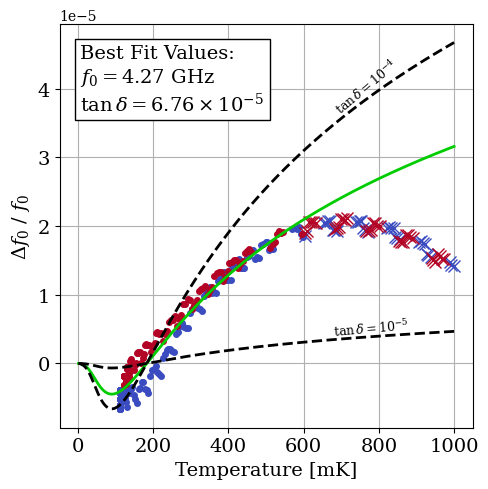

In [123]:
# Make the dF/F plot for just one rez
res_fit_f0s = [4269546157.4128857, 4563873864.112862, 5004736212.4262, 5214629886.607329, 5655909394.96603] # So we don't have to redo fits.
res_fit_tands = [6.7622e-05, 0.41e-4, 0.60e-4, 0.81e-4, 5.6701e-05]
resnum = 0
f0 = res_fit_f0s[resnum]
Fd = res_fit_tands[resnum]
tfitmax = 600 # mK
tfitmin = 0 # mK
tplotmax = 1000 # mK
npwrs = len(sweep.pvec)
cmap = plt.get_cmap('coolwarm')
colors = cmap(np.linspace(0, 1, npwrs))
ms = 8 # Marker Size
lw = 2 # line Width

best_fit_params = {
    "f0" : f0,
    "Fd" : Fd,
}
params = params_from_dict(best_fit_params)

sweep = resSweeps[resnum]
sweep.lmfit_results["f0_tls_only"] = do_lmfit_ragged(
            sweep,
            f0_tls,
            params,
            param_name="f0",
            min_temp=tfitmin,
            max_temp=tfitmax,
            method='least_squares',
            minimize_kws=dict(max_nfev=8000, ftol=1e-10, xtol=1e-10, gtol=1e-10),
        )

params = sweep.lmfit_results["f0_tls_only"].params
f0 = params["f0"].value
Fd = params["Fd"].value

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "dejavuserif",
})
fig = plt.figure("df_vs_T",figsize=(5,5))
plt.clf()
ax = plt.gca()

sweep = resSweeps_MagUp[resnum]
# Real Data
for pidx, pwr in enumerate(sweep.pvec):
    fitidx = (sweep.tvec <= tfitmax) & (sweep.tvec >= tfitmin)
    fitdata = sweep["f0"][pwr].iloc[fitidx]
    plt.plot(
        sweep.tvec[fitidx],
        (fitdata - f0) / f0,
        '.',
        label=f'{pwr} dB',
        #color=colors[pidx],
        color=colors[0],
        ms=ms,
    )

    plotidx = (sweep.tvec <= tplotmax) & (sweep.tvec >= tfitmax)
    plotdata = sweep["f0"][pwr].iloc[plotidx]
    plt.plot(
        sweep.tvec[plotidx],
        (plotdata - f0) / f0,
        'x',
        #color=np.clip(colors[pidx] + 0.3, 0, 1),
        color=colors[0],
        ms=ms,
    )

sweep = resSweeps_MagDown[resnum]
# Real Data
for pidx, pwr in enumerate(sweep.pvec):
    fitidx = (sweep.tvec <= tfitmax) & (sweep.tvec >= tfitmin)
    fitdata = sweep["f0"][pwr].iloc[fitidx]
    plt.plot(
        sweep.tvec[fitidx],
        (fitdata - f0) / f0,
        '.',
        label=f'{pwr} dB',
        #color=colors[pidx],
        color=colors[-1],
        ms=ms,
    )

    plotidx = (sweep.tvec <= tplotmax) & (sweep.tvec >= tfitmax)
    plotdata = sweep["f0"][pwr].iloc[plotidx]
    plt.plot(
        sweep.tvec[plotidx],
        (plotdata - f0) / f0,
        'x',
        #color=np.clip(colors[pidx] + 0.3, 0, 1),
        color=colors[-1],
        ms=ms,
    )


# Models
T = np.linspace(0,tplotmax,500)

# Best-fit Model
model = (f0_tls(params,T,0)-f0)/f0
plt.plot(T,model,color=[0,0.8,0],lw=lw)

# Tand = 1e-4
dummyparm = params.copy()
dummyparm['Fd'].value = 1e-4
model = (f0_tls(dummyparm,T,0)-f0)/f0
plt.plot(T,model,'k--',lw=lw)

# Tand = 1e-5
dummyparm = params.copy()
dummyparm['Fd'].value = 1e-5
model = (f0_tls(dummyparm,T,0)-f0)/f0
plt.plot(T,model,'k--',lw=lw)

## Text
# Best fit values
ax.text(
    0.05, 0.95,
    f"Best Fit Values:\n$f_0={f0/1e9:0.2f}$ GHz\n$\\tan\\delta={Fd*1e5:0.2f}"+"\\times 10^{-5}$",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=14,
    bbox=dict(
        boxstyle="square,pad=0.3",
        facecolor="white",
        edgecolor="black"
    )
)

ax.text(0.66,0.8,"$\\tan\\delta=10^{-4}$",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9, 
    rotation=40, 
    rotation_mode='anchor',
       )

ax.text(0.66,0.26,"$\\tan\\delta=10^{-5}$",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=9, 
    rotation=5, 
    rotation_mode='anchor',
       )


ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)
plt.xlabel("Temperature [mK]",fontsize=14)
plt.ylabel("$\\Delta f_0\\,\\,/\\,\\,f_0$",fontsize=14)

plt.grid(True)
plt.tight_layout()
#plt.show()
#plt.savefig('paper_plot_df_vs_t.png',dpi=300)
plt.savefig('paper_plot_df_vs_t.pdf',dpi=300)
